# 03 - RFM analysis
**Question:** which customers are the most valuable, and which of them have gone quiet?

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from src.config import *
from src import eda, evaluation as ev
from src.feature_engineering import *
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

In [2]:
customers = pd.read_csv(DATA_PROC / "customers_clean.csv", parse_dates=["customer_registration_date"])
tx = pd.read_csv(DATA_PROC / "transactions_clean.csv.gz", parse_dates=["date"])
orders = build_orders(tx); lines, returns = tx[~tx.is_return], tx[tx.is_return]
M = json.load(open(DATA_PROC / "metrics.json")); H = M["H"]
meta = json.load(open(DATA_PROC / "run_metadata.json"))
START, END = pd.Timestamp(M["data_start"]), pd.Timestamp(M["data_end"])
FEATURES_USED = meta["features_used"]
train_c = [pd.Timestamp(c) for c in M["train_cutoffs"]]; val_c = pd.Timestamp(M["val_cutoff"]); test_c = pd.Timestamp(M["test_cutoff"])
display(Markdown(f"> **Dataset: {meta['name']}** ({'SIMULATED' if meta['kind'] == 'synthetic' else 'real'}) | {M['data_start']} -> {M['data_end']} | churn window **{H} days** ({M['churn_window_source']}). "
                 "All numbers in the commentary below are computed from this dataset when the notebook runs."))

> **Dataset: online_retail_ii** (real) | 2009-12-01 -> 2011-12-09 | churn window **180 days** (P95 of purchase gaps = 221 days, rounded up to a multiple of 15). All numbers in the commentary below are computed from this dataset when the notebook runs.

In [3]:
from src.segmentation import rfm_scores, rfm_segments, SEGMENT_RULES
f = compute_features(orders, lines, returns, customers, END)
rfm = rfm_segments(rfm_scores(f))
rfm["status"] = np.where(rfm.recency_days <= H, "Active", "Lapsed")
print(SEGMENT_RULES)
display(rfm[["recency_days","frequency","monetary","R","F","M","RFM_score","rfm_segment"]].head())


Segments are assigned top-to-bottom; the first rule that matches wins. FM = (F + M) / 2.
 1. New customers        first order <= 60 days ago AND <= 2 orders (too little history to judge value)
 2. Champions            R >= 4 AND FM >= 4          (recent, frequent, high spend)
 3. Loyal customers      R >= 3 AND FM >= 3.5        (solid repeat buyers, reasonably recent)
 4. At-risk customers    R <= 2 AND FM >= 3          (used to be good, now quiet -> valuable but slipping)
 5. Potential loyalists  R >= 3                      (recent, but not yet frequent/high-spend)
 6. Hibernating          everything else (R <= 2, low FM)



,recency_days,frequency,monetary,R,F,M,RFM_score,rfm_segment
customer_id,,,,,,,,
12346,325,3,77352.96,2,3,5,235,At-risk customers
12347,2,8,4921.53,5,4,5,545,Champions
12348,75,5,1658.40,3,4,4,344,Loyal customers
12349,18,3,3678.69,5,3,5,535,Champions
12350,310,1,294.40,2,1,2,212,Hibernating


**Scoring logic.** Each of R, F, M gets a 1-5 score from percentile rank, so ties share a score (no arbitrary tie-breaking: the many one-order customers all get the same F). Recency is inverted so that 5 = most recent. Segment names are *labels for rules*, so we verify afterwards that the data supports them.

,customers,revenue,median_recency,median_frequency,median_spend,lapsed_share,customer_share,revenue_share
rfm_segment,,,,,,,,
At-risk customers,645,1610639.70,367.0,4.0,1341.85,1.00,0.11,0.09
Champions,1283,11684994.57,16.0,11.0,3944.88,0.00,0.22,0.68
Hibernating,1694,605031.42,427.5,1.0,297.48,1.00,0.29,0.04
Loyal customers,795,2339208.93,74.0,6.0,1817.54,0.02,0.14,0.14
New customers,323,134339.34,25.0,1.0,301.29,0.00,0.06,0.01
Potential loyalists,1112,694335.16,63.0,2.0,566.66,0.02,0.19,0.04


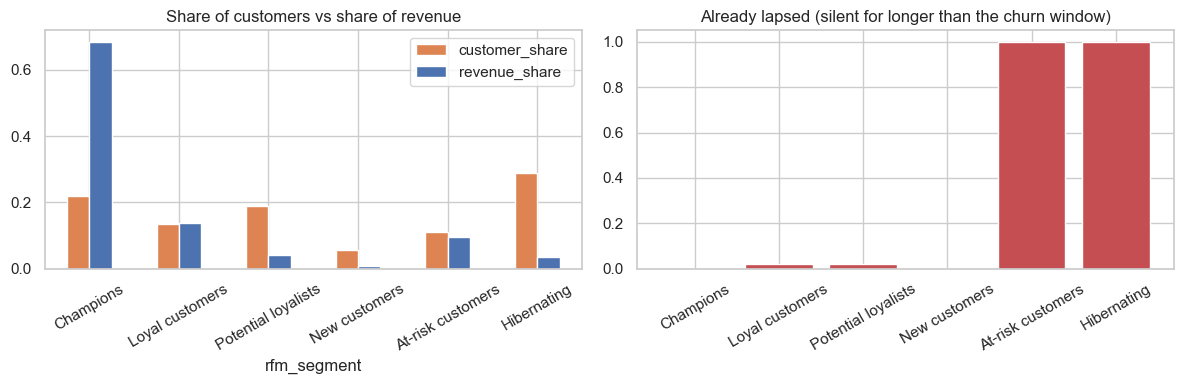

**So what?**
* **At-risk customers**: 645 customers (11%), **9% of revenue**, median recency 367 d, median 4 orders, 100% already beyond the 180-day churn window
* **Champions**: 1,283 customers (22%), **68% of revenue**, median recency 16 d, median 11 orders, 0% already beyond the 180-day churn window
* **Hibernating**: 1,694 customers (29%), **4% of revenue**, median recency 428 d, median 1 orders, 100% already beyond the 180-day churn window
* **Loyal customers**: 795 customers (14%), **14% of revenue**, median recency 74 d, median 6 orders, 2% already beyond the 180-day churn window
* **New customers**: 323 customers (6%), **1% of revenue**, median recency 25 d, median 1 orders, 0% already beyond the 180-day churn window
* **Potential loyalists**: 1,112 customers (19%), **4% of revenue**, median recency 63 d, median 2 orders, 2% already beyond the 180-day churn window

* Segments with no customers do not appear: a business label is only shown when the data supports it.
* RFM is *descriptive*: segments defined by poor recency are mostly already past the churn window. Predicting who is *about to* leave needs the churn model (notebook 05), applied to customers who are still active.


In [4]:
seg = pd.read_csv(DATA_PROC / "rfm_segment_summary.csv").set_index("rfm_segment")
display(seg.round(2))
eda.fig_rfm(seg); plt.show()
rq = meta["rfm_quality"]
bul = [f"* **{n}**: {r.customers:,.0f} customers ({r.customer_share:.0%}), **{r.revenue_share:.0%} of revenue**, median recency {r.median_recency:.0f} d, median {r.median_frequency:.0f} orders, {r.lapsed_share:.0%} already beyond the {H}-day churn window" for n, r in seg.iterrows()]
display(Markdown("**So what?**\n" + "\n".join(bul) + f"\n\n* Segments with no customers do not appear: a business label is only shown when the data supports it.\n"
    "* RFM is *descriptive*: segments defined by poor recency are mostly already past the churn window. Predicting who is *about to* leave needs the churn model (notebook 05), applied to customers who are still active.\n"
    + "".join(f"* WARNING: {w}\n" for w in rq["warnings"])))